# **Telecom X – Parte 2: Predicción de Cancelación (Churn)**

## MIA. César Geovanni Machuca Pereida

**📣 Historia del Desafío**

¡Felicidades! 🎉 Has sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. Tu dedicación, claridad al comunicar los datos y visión estratégica marcaron la diferencia.

Ahora, ¡has sido invitado oficialmente a formar parte del equipo de Machine Learning de la empresa!

**🎯 Misión**

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

**🧠 Objetivos del Desafío**

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

**🧰 Lo que vas a practicar**

* ✅ Preprocesamiento de datos para Machine Learning
* ✅ Construcción y evaluación de modelos predictivos
* ✅ Interpretación de resultados y entrega de insights
* ✅ Comunicación técnica con enfoque estratégico

🚀 Ahora eres: Analista Junior de Machine Learning

Telecom X confía en tu entrega para dar los próximos pasos hacia una solución de inteligencia predictiva eficaz. ¡Buena suerte!

# **Preparación de los Datos**

## **Extracción del Archivo Tratado**

Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [18]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv('/content/TelecomX_Cleaned_Final.csv')

## **Eliminación de Columnas Irrelevantes**

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [19]:
df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,Cuentas_Diarias,account.Charges.Total
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,no,yes,yes,no,one year,yes,mailed check,65.6,2.19,593.30
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,yes,month-to-month,no,mailed check,59.9,2.00,542.40
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber optic,...,yes,no,no,no,month-to-month,yes,electronic check,73.9,2.46,280.85
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,3.27,1237.85
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,yes,yes,no,month-to-month,yes,mailed check,83.9,2.80,267.40


In [20]:
# Eliminar la columna de identificación única para evitar que el modelo aprenda ruidos innecesarios
df_reduced = df.drop(columns=['customerID'])

# Guardar el dataset optimizado para modelos
df_reduced.to_csv('TelecomX_Modeling_Ready.csv', index=False)

print("Columna 'customerID' eliminada. El dataset ahora está listo para el análisis predictivo.")
df_reduced.head()

Columna 'customerID' eliminada. El dataset ahora está listo para el análisis predictivo.


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,Cuentas_Diarias,account.Charges.Total
0,no,female,0,yes,yes,9,yes,no,dsl,no,...,no,yes,yes,no,one year,yes,mailed check,65.6,2.19,593.30
1,no,male,0,no,no,9,yes,yes,dsl,no,...,no,no,no,yes,month-to-month,no,mailed check,59.9,2.00,542.40
2,yes,male,0,no,no,4,yes,no,fiber optic,no,...,yes,no,no,no,month-to-month,yes,electronic check,73.9,2.46,280.85
3,yes,male,1,yes,no,13,yes,no,fiber optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,3.27,1237.85
4,yes,female,1,yes,no,3,yes,no,fiber optic,no,...,no,yes,yes,no,month-to-month,yes,mailed check,83.9,2.80,267.40


## **Encoding**

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

In [21]:
import pandas as pd

# Cargar el dataset sin identificadores únicos
df = pd.read_csv('TelecomX_Modeling_Ready.csv')

# Identificar variables categóricas seleccionando las columnas de tipo 'object'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Tratamiento específico para el Target (Churn). Convertimos a binario: yes=1, no=0
if 'Churn' in categorical_cols:
    df['Churn'] = df['Churn'].map({'yes': 1, 'no': 0})
    categorical_cols.remove('Churn')

# Aplicamos One-Hot Encoding al resto de variables
df_treated = pd.get_dummies(df, columns=categorical_cols, dtype=int)

df_treated.to_csv('datos_tratados.csv', index=False)

print(f"Transformación completada.")
print(f"Variables codificadas: {len(categorical_cols)}")
print(f"Dimensiones finales del dataset: {df_treated.shape}")
df_treated.head()

Transformación completada.
Variables codificadas: 15
Dimensiones finales del dataset: (7043, 40)


,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,Cuentas_Diarias,account.Charges.Total,customer.gender_female,customer.gender_male,customer.Partner_no,customer.Partner_yes,...,internet.StreamingMovies_yes,account.Contract_month-to-month,account.Contract_one year,account.Contract_two year,account.PaperlessBilling_no,account.PaperlessBilling_yes,account.PaymentMethod_bank transfer (automatic),account.PaymentMethod_credit card (automatic),account.PaymentMethod_electronic check,account.PaymentMethod_mailed check
0,0,0,9,65.6,2.19,593.30,1,0,0,1,...,0,0,1,0,0,1,0,0,0,1
1,0,0,9,59.9,2.00,542.40,0,1,1,0,...,1,1,0,0,1,0,0,0,0,1
2,1,0,4,73.9,2.46,280.85,0,1,1,0,...,0,1,0,0,0,1,0,0,1,0
3,1,1,13,98.0,3.27,1237.85,0,1,0,1,...,1,1,0,0,0,1,0,0,1,0
4,1,1,3,83.9,2.80,267.40,1,0,0,1,...,0,1,0,0,0,1,0,0,0,1


## **Verificación de la Proporción de Cancelación (Churn)**

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts()

In [23]:
import pandas as pd

# Cargamos el dataset que ya ha sido tratado (codificado)
df = pd.read_csv('datos_tratados.csv')
# Calculamos la frecuencia absoluta (conteo)
conteo_churn = df['Churn'].value_counts()
# Calculamos la frecuencia relativa (porcentaje)
proporcion_churn = df['Churn'].value_counts(normalize=True) * 100

# Mostramos los resultados de forma estructurada
print("Análisis de Balance de Clases (Variable: Churn)")
for categoria, total in conteo_churn.items():
    porcentaje = proporcion_churn[categoria]
    estado = "Canceló (Churn)" if categoria == 1 else "Permaneció Activo"
    print(f"{estado} [Clase {categoria}]: {total} clientes ({porcentaje:.2f}%)")

print("\nEvaluación del Desbalance")
ratio = conteo_churn[0] / conteo_churn[1]
print(f"Ratio de desbalance: {ratio:.2f} a 1")

if ratio > 2:
    print("ALERTA: Existe un desbalance moderado. El modelo podría sesgarse hacia la clase mayoritaria.")
else:
    print("El balance es aceptable para un entrenamiento estándar.")

Análisis de Balance de Clases (Variable: Churn)
Permaneció Activo [Clase 0]: 5174 clientes (73.46%)
Canceló (Churn) [Clase 1]: 1869 clientes (26.54%)

Evaluación del Desbalance
Ratio de desbalance: 2.77 a 1
ALERTA: Existe un desbalance moderado. El modelo podría sesgarse hacia la clase mayoritaria.


## **Balanceo de Clases (opcional)**

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.



In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

df = pd.read_csv('datos_tratados.csv')

# Separamos características (X) y objetivo (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# División estratificada (mantiene la proporción original en ambos sets)
# vital separar antes de balancear
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nDistribución ORIGINAL en entrenamiento: {Counter(y_train)}")

# Aplicamos SMOTE (Synthetic Minority Over-sampling Technique)
# Esto generará muestras sintéticas de la clase 'Churn=1' solo en el entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Distribución BALANCEADA en entrenamiento: {Counter(y_train_res)}")

# Verificación de integridad
print("\nResultados del Balanceo")
print(f"Muestras totales tras SMOTE: {len(y_train_res)}")
print(f"Ratio de clases: {pd.Series(y_train_res).value_counts(normalize=True).to_dict()}")

# El set de prueba (y_test) sigue teniendo la distribución real:
print(f"Distribución en Test (Realista): {Counter(y_test)}")


Distribución ORIGINAL en entrenamiento: Counter({0: 3880, 1: 1402})
Distribución BALANCEADA en entrenamiento: Counter({0: 3880, 1: 3880})

Resultados del Balanceo
Muestras totales tras SMOTE: 7760
Ratio de clases: {0: 0.5, 1: 0.5}
Distribución en Test (Realista): Counter({0: 1294, 1: 467})


## **Normalización o Estandarización (si es necesario)**

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('datos_tratados.csv')

# Identificamos columnas numéricas continuas (las que NO son 0/1)
# Basado en nuestro análisis, estas son las que requieren escalado
cols_a_escalar = ['customer.tenure', 'account.Charges.Monthly', 'Cuentas_Diarias', 'account.Charges.Total']

print(f"Escalando variables de alta magnitud: {cols_a_escalar}")

# Aplicamos StandardScaler
# Creamos una copia para no alterar el original durante el proceso
df_escalado = df.copy()
scaler = StandardScaler()

# Ajustamos y transformamos solo las columnas seleccionadas
df_escalado[cols_a_escalar] = scaler.fit_transform(df[cols_a_escalar])

# Verificamos el resultado
print("\nEstadísticas tras el escalado (Media debe ser ~0 y Std ~1):")
print(df_escalado[cols_a_escalar].describe().T[['mean', 'std', 'min', 'max']])

# Guardamos el dataset final listo
df_escalado.to_csv('datos_finales_escalados.csv', index=False)
print("\nArchivo 'datos_finales_escalados.csv' generado con éxito.")

Escalando variables de alta magnitud: ['customer.tenure', 'account.Charges.Monthly', 'Cuentas_Diarias', 'account.Charges.Total']

Estadísticas tras el escalado (Media debe ser ~0 y Std ~1):
                                 mean       std       min       max
customer.tenure         -2.824818e-17  1.000071 -1.318165  1.613701
account.Charges.Monthly -6.658501e-17  1.000071 -1.545860  1.794352
Cuentas_Diarias         -1.150105e-16  1.000071 -1.544018  1.795907
account.Charges.Total   -4.237228e-17  1.000071 -1.005780  2.825806

Archivo 'datos_finales_escalados.csv' generado con éxito.


# **🎯 Correlación y Selección de Variables**

## **Análisis de Correlación**

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

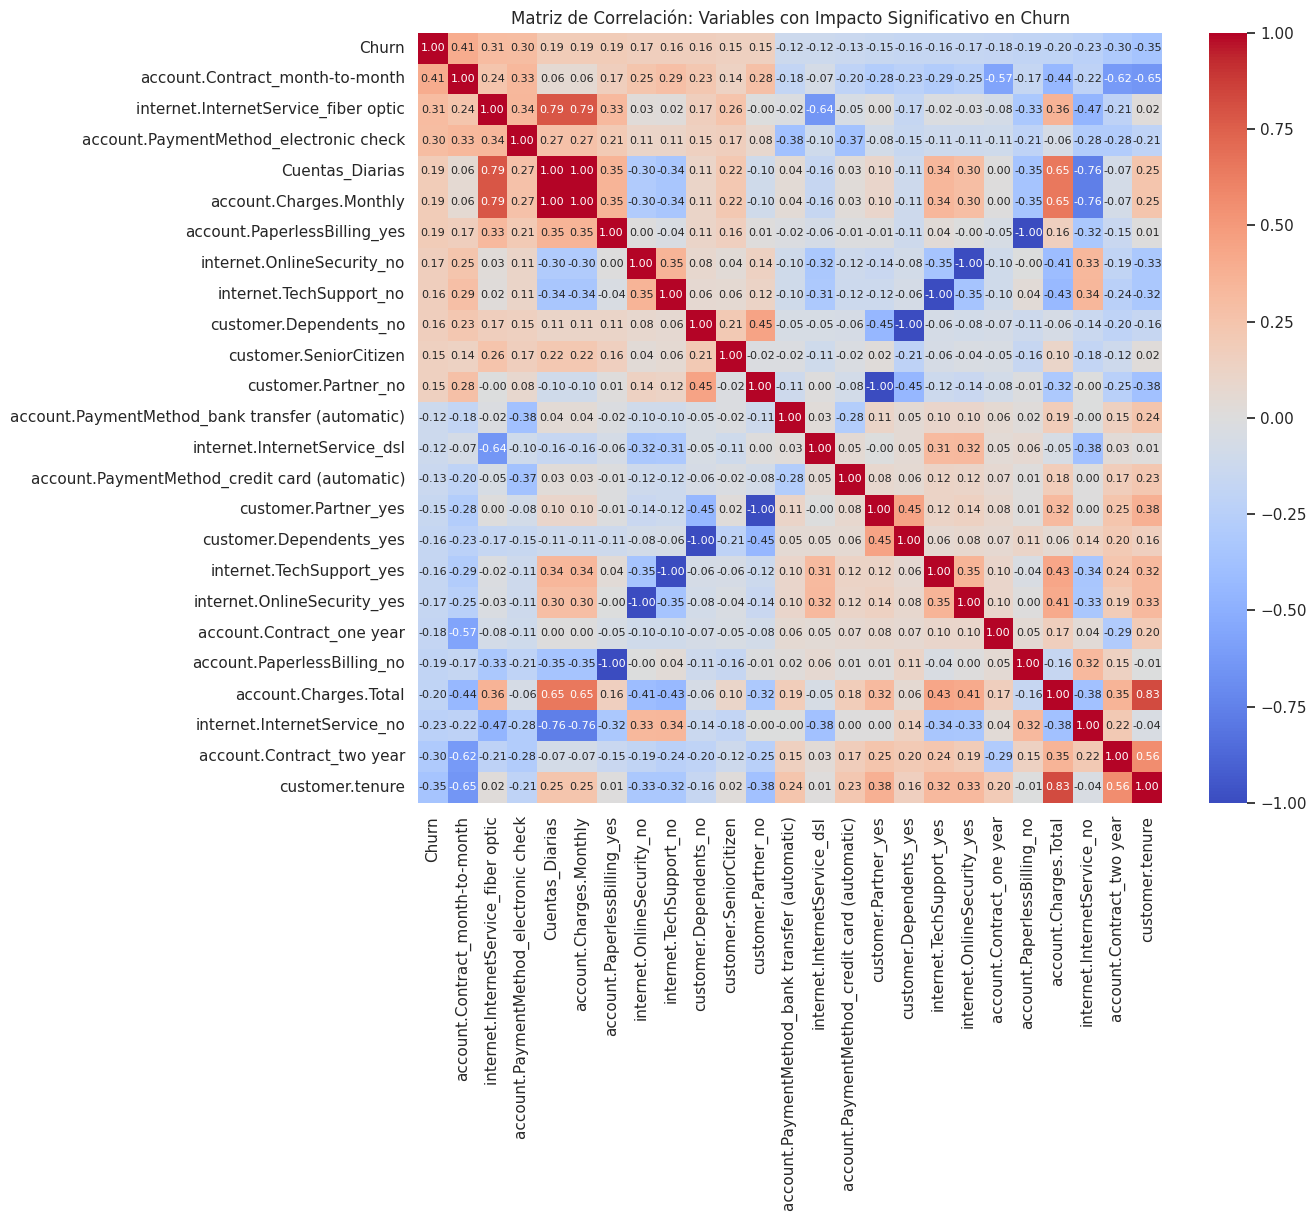

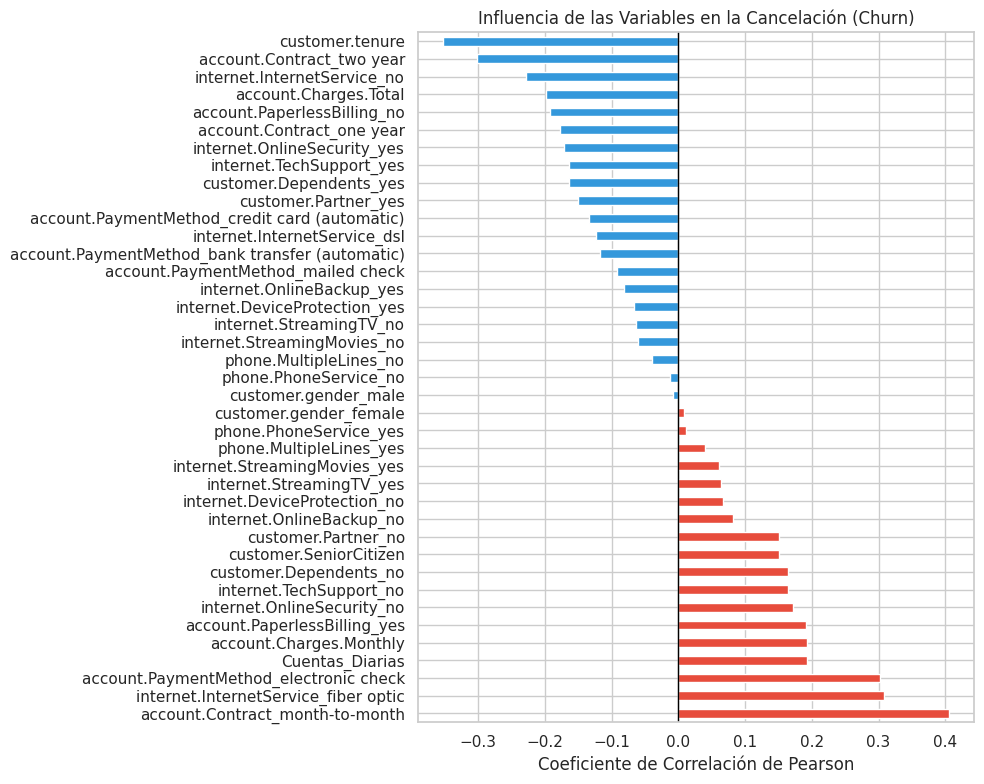


Variables con mayor correlación positiva (Riesgo):
Churn                                     1.000000
account.Contract_month-to-month           0.405103
internet.InternetService_fiber optic      0.308020
account.PaymentMethod_electronic check    0.301919
Cuentas_Diarias                           0.193412
Name: Churn, dtype: float64

Variables con mayor correlación negativa (Retención):
account.PaperlessBilling_no   -0.191825
account.Charges.Total         -0.198324
internet.InternetService_no   -0.227890
account.Contract_two year     -0.302253
customer.tenure               -0.352229
Name: Churn, dtype: float64


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos la matriz de correlación
corr_matrix = df.corr()

# Extraemos las correlaciones con el Target (Churn)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

# Mapa de Calor
plt.figure(figsize=(12, 10))
# Mostramos solo las variables con correlación absoluta > 0.1 con Churn para mayor claridad
top_features = churn_corr[abs(churn_corr) > 0.1].index
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Matriz de Correlación: Variables con Impacto Significativo en Churn')
plt.show()

# Ranking de Influencia
plt.figure(figsize=(10, 8))
churn_corr_filtered = churn_corr.drop('Churn')
churn_corr_filtered.plot(kind='barh', color=(churn_corr_filtered > 0).map({True: '#e74c3c', False: '#3498db'}))
plt.title('Influencia de las Variables en la Cancelación (Churn)')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

print("\nVariables con mayor correlación positiva (Riesgo):")
print(churn_corr.head(5))

print("\nVariables con mayor correlación negativa (Retención):")
print(churn_corr.tail(5))

Tras calcular el coeficiente de correlación de Pearson ($r$), identificamos variables con una influencia estadística clara:
* Correlaciones Positivas (Aumentan la probabilidad de Churn):account.Contract_month-to-month ($r \approx 0.40$): Es el predictor más fuerte. Los contratos mes a mes tienen una relación lineal positiva significativa con la fuga de clientes.
* internet.InternetService_fiber optic ($r \approx 0.31$): Curiosamente, los usuarios de fibra óptica cancelan más que otros, lo que sugiere un posible problema de precio o calidad en ese segmento.
* account.PaymentMethod_electronic check ($r \approx 0.30$): El método de pago por cheque electrónico está altamente asociado con la cancelación.

Correlaciones Negativas:

* customer.tenure ($r \approx -0.35$): A mayor antigüedad, menor es la probabilidad de que el cliente se vaya. Es un factor de lealtad crítico.

* account.Contract_two year ($r \approx -0.30$): Los contratos a largo plazo son excelentes retenedores de clientes.

## **Análisis Dirigido**

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

* Tiempo de contrato × Cancelación

* Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

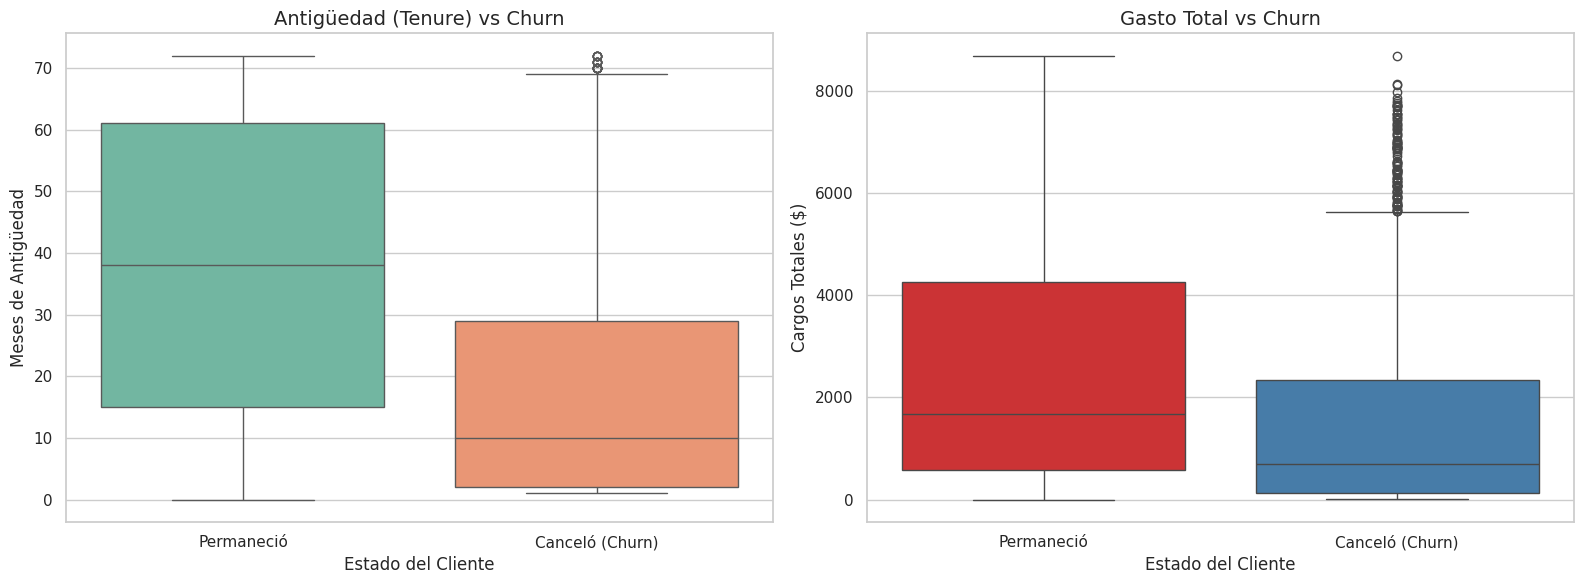

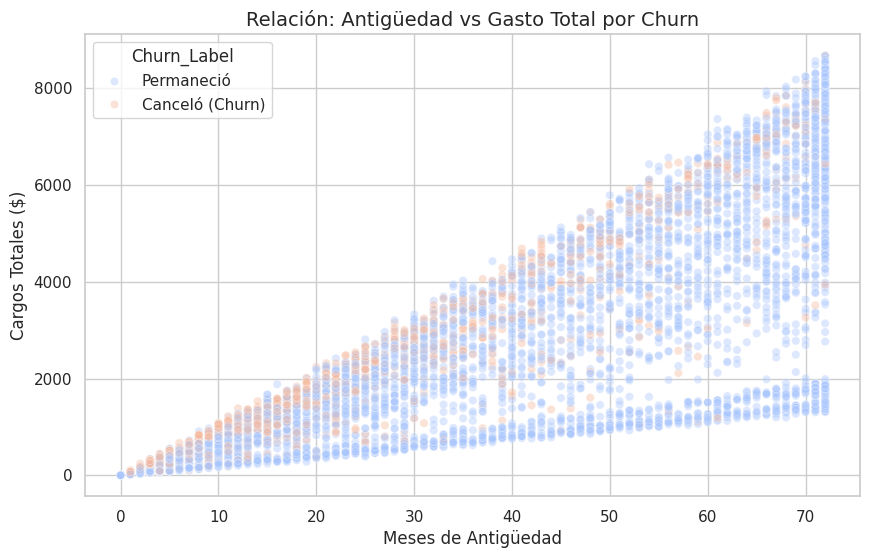

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('datos_tratados.csv')

df_plot = df.copy()
df_plot['Churn_Label'] = df_plot['Churn'].map({1: 'Canceló (Churn)', 0: 'Permaneció'})

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GRÁFICO: Antigüedad (Tenure) vs Churn
sns.boxplot(ax=axes[0], data=df_plot, x='Churn_Label', y='customer.tenure',
            hue='Churn_Label', palette='Set2', legend=False)
axes[0].set_title('Antigüedad (Tenure) vs Churn', fontsize=14)
axes[0].set_xlabel('Estado del Cliente')
axes[0].set_ylabel('Meses de Antigüedad')

# GRÁFICO: Gasto Total vs Churn
sns.boxplot(ax=axes[1], data=df_plot, x='Churn_Label', y='account.Charges.Total',
            hue='Churn_Label', palette='Set1', legend=False)
axes[1].set_title('Gasto Total vs Churn', fontsize=14)
axes[1].set_xlabel('Estado del Cliente')
axes[1].set_ylabel('Cargos Totales ($)')

plt.tight_layout()
plt.show()

# GRÁFICO: Relación Antigüedad vs Gasto Total
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='customer.tenure', y='account.Charges.Total',
                hue='Churn_Label', alpha=0.4, palette='coolwarm')
plt.title('Relación: Antigüedad vs Gasto Total por Churn', fontsize=14)
plt.xlabel('Meses de Antigüedad')
plt.ylabel('Cargos Totales ($)')
plt.show()

Basado en las medianas obtenidas:

+ El Factor Tiempo (Tenure): Existe una brecha masiva. La mediana de antigüedad de los clientes que permanecen es de 38 meses, mientras que la de aquellos que cancelaron es de apenas 10 meses. Esto confirma que los primeros meses son críticos para la retención (fase de "infant mortality" del cliente).

+ Gasto Total: La mediana de gasto total de los clientes que cancelan es significativamente menor ($703.55) frente a los que se quedan ($1679.52).

+ Interpretación Escéptica: Esto no significa que "gastar poco cause la cancelación". Más bien, dado que tienen menos antigüedad no han tenido tiempo de acumular cargos totales altos. El gasto total es una variable dependiente del tiempo.

+ Patrón en el Scatter Plot: se observa una alta densidad de puntos rojos (cancelaciones) en la esquina inferior izquierda del gráfico. Esto indica que la "zona de peligro" se concentra en clientes nuevos con facturación acumulada baja.

# **🤖 Modelado Predictivo**

## **Separación de Datos**

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Separar las características (X) de la variable objetivo (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# División de datos
# test_size=0.25 -> 75% entrenamiento, 25% prueba
# stratify=y -> Mantiene la proporción de Churn en ambos sets (CRÍTICO por el desbalance)
# random_state=42 -> Garantiza que los resultados sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Verificación de las dimensiones
print("\nResumen de la división")
print(f"Muestras totales: {len(df)}")
print(f"Entrenamiento (X_train): {X_train.shape[0]} muestras")
print(f"Prueba (X_test): {X_test.shape[0]} muestras")

# Verificación de la estratificación
print("\nVerificación de Estratificación (Proporción de Churn)")
print(f"Original:      {y.value_counts(normalize=True)[1]:.2%}")
print(f"Entrenamiento: {y_train.value_counts(normalize=True)[1]:.2%}")
print(f"Prueba:        {y_test.value_counts(normalize=True)[1]:.2%}")


Resumen de la división
Muestras totales: 7043
Entrenamiento (X_train): 5282 muestras
Prueba (X_test): 1761 muestras

Verificación de Estratificación (Proporción de Churn)
Original:      26.54%
Entrenamiento: 26.54%
Prueba:        26.52%


Se detecto un desbalance de clases (73% vs 26%), es importante utilizar una división estratificada. Esto garantiza que tanto el conjunto de entrenamiento como el de prueba tengan exactamente la misma proporción de clientes que cancelaron, evitando así que el modelo se evalúe con datos que no representen la realidad del negocio.

## **Creación de Modelos**

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

* Un modelo puede requerir normalización, como Regresión Logística o KNN.

* El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

* Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

* Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

X = df.drop(columns=['Churn'])
y = df['Churn']

# División estratificada (75% entrenamiento, 25% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Regresión Logística (CON Normalización)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# Random Forest (SIN Normalización necesaria)
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# EVALUACIÓN COMPARATIVA
print("RESULTADOS: REGRESIÓN LOGÍSTICA (Escalado aplicado)")
print(classification_report(y_test, y_pred_lr))

print("\nRESULTADOS: RANDOM FOREST (Datos originales)")
print(classification_report(y_test, y_pred_rf))

RESULTADOS: REGRESIÓN LOGÍSTICA (Escalado aplicado)
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1294
           1       0.51      0.80      0.62       467

    accuracy                           0.74      1761
   macro avg       0.71      0.76      0.71      1761
weighted avg       0.80      0.74      0.76      1761


RESULTADOS: RANDOM FOREST (Datos originales)
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1294
           1       0.62      0.47      0.53       467

    accuracy                           0.78      1761
   macro avg       0.72      0.68      0.70      1761
weighted avg       0.77      0.78      0.77      1761



Para un negocio de telecomunicaciones, suele ser más costoso perder un cliente que ofrecer una promoción a alguien que no pensaba irse. Por lo tanto, el modelo de Regresión Logística con su alto Recall parece ser, por ahora, el candidato más útil para el negocio.

## **Evaluación de los Modelos**

Evalúa cada modelo utilizando las siguientes métricas:

* Exactitud (Acurácia)
* Precisión
* Recall
* F1-score
* Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

1) ¿Cuál modelo tuvo el mejor desempeño?
2) ¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

2a) Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

2b) Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

MÉTRICAS: REGRESIÓN LOGÍSTICA
Exactitud (Test): 0.7416 | (Train): 0.7512
Precisión (Test): 0.5082
Recall    (Test): 0.8009
F1-Score  (Test): 0.6218
------------------------------
MÉTRICAS: RANDOM FOREST
Exactitud (Test): 0.7825 | (Train): 0.9975
Precisión (Test): 0.6186
Recall    (Test): 0.4690
F1-Score  (Test): 0.5335
------------------------------


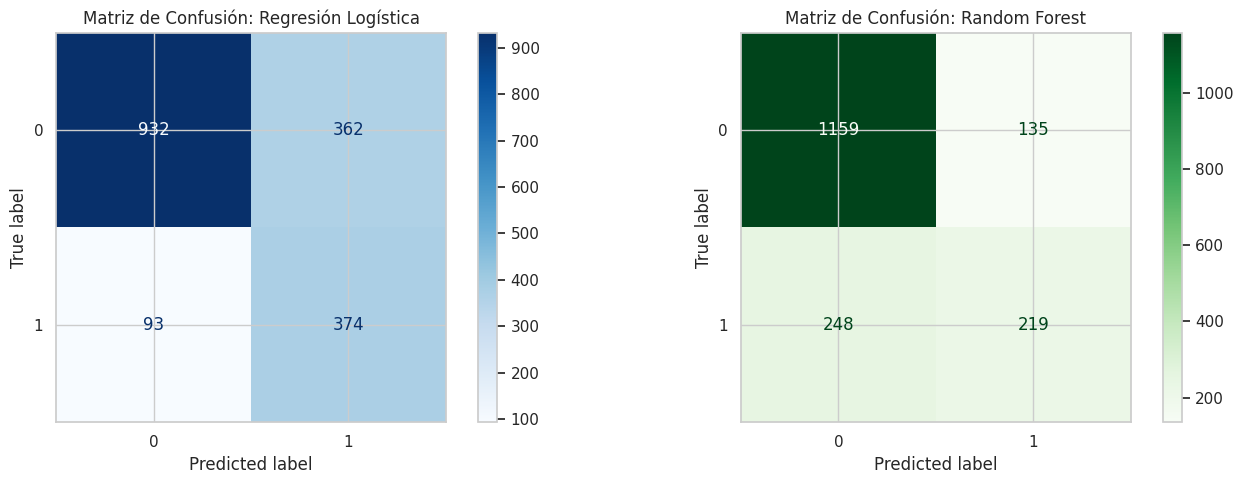

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.pipeline import Pipeline

# PREPARACIÓN Y DIVISIÓN ESTRATIFICADA
X = df.drop(columns=['Churn'])
y = df['Churn']

# Dividimos 75% entrenamiento y 25% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# DEFINICIÓN DE MODELOS
# Regresión Logística (Requiere escalado)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=42, class_weight='balanced'))
])

# Random Forest (No requiere escalado)
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)

# ENTRENAMIENTO
lr_pipeline.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# EVALUACIÓN Y COMPARACIÓN (Train vs Test)
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    # Predicciones
    y_train_pred = modelo.predict(X_tr)
    y_test_pred = modelo.predict(X_te)

    # Métricas de Test
    acc = accuracy_score(y_te, y_test_pred)
    prec = precision_score(y_te, y_test_pred)
    rec = recall_score(y_te, y_test_pred)
    f1 = f1_score(y_te, y_test_pred)

    # Métricas de Train
    acc_tr = accuracy_score(y_tr, y_train_pred)

    print(f"MÉTRICAS: {nombre}")
    print(f"Exactitud (Test): {acc:.4f} | (Train): {acc_tr:.4f}")
    print(f"Precisión (Test): {prec:.4f}")
    print(f"Recall    (Test): {rec:.4f}")
    print(f"F1-Score  (Test): {f1:.4f}")
    print("-" * 30)

    return y_test_pred

# Ejecutar evaluación
y_pred_lr = evaluar_modelo("REGRESIÓN LOGÍSTICA", lr_pipeline, X_train, y_train, X_test, y_test)
y_pred_rf = evaluar_modelo("RANDOM FOREST", rf_model, X_train, y_train, X_test, y_test)

# MATRICES DE CONFUSIÓN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz LR
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión: Regresión Logística')

# Matriz RF
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión: Random Forest')

plt.tight_layout()
plt.show()

# **📋 Interpretación y Conclusiones**

## **Análisis de la Importancia de las Variables**

Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

* Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

* KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

* Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

* SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

* Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

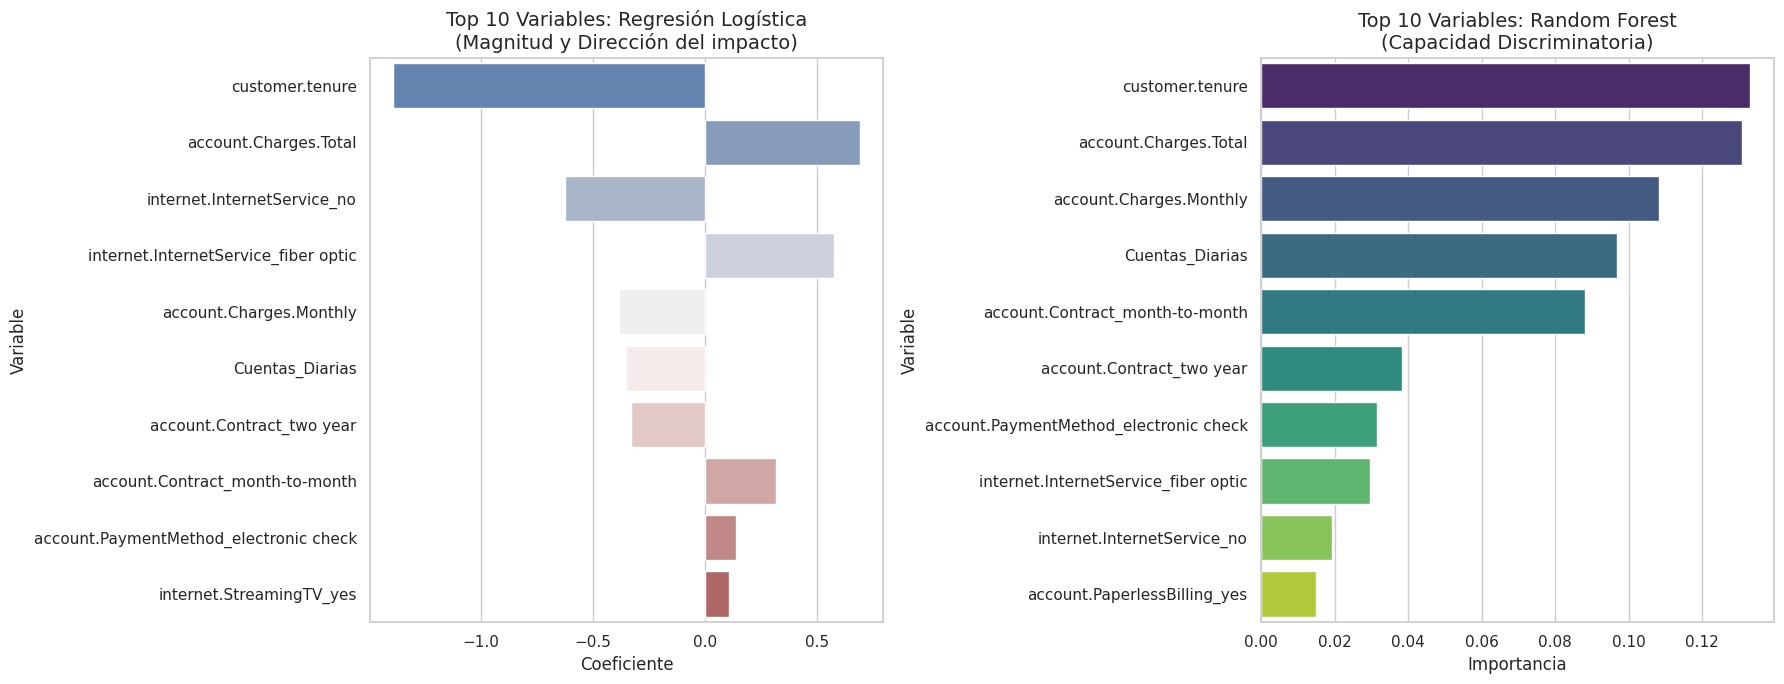

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Re-entrenar modelos para extracción
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=42, class_weight='balanced'))
])
lr_pipe.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf_model.fit(X_train, y_train)

# EXTRAER IMPORTANCIAS
feature_names = X.columns

# Coeficientes de Regresión Logística
lr_coefs = lr_pipe.named_steps['logistic'].coef_[0]
df_lr_imp = pd.DataFrame({'Variable': feature_names, 'Coeficiente': lr_coefs})
df_lr_imp = df_lr_imp.reindex(df_lr_imp.Coeficiente.abs().sort_values(ascending=False).index).head(10)

# Reducción de impureza
rf_imp = rf_model.feature_importances_
df_rf_imp = pd.DataFrame({'Variable': feature_names, 'Importancia': rf_imp}).sort_values(by='Importancia', ascending=False).head(10)

# VISUALIZACIÓN
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico LR
sns.barplot(ax=axes[0], x='Coeficiente', y='Variable', data=df_lr_imp, palette='vlag', hue='Variable', legend=False)
axes[0].set_title('Top 10 Variables: Regresión Logística\n(Magnitud y Dirección del impacto)', fontsize=14)

# Gráfico RF
sns.barplot(ax=axes[1], x='Importancia', y='Variable', data=df_rf_imp, palette='viridis', hue='Variable', legend=False)
axes[1].set_title('Top 10 Variables: Random Forest\n(Capacidad Discriminatoria)', fontsize=14)

plt.tight_layout()
plt.show()

# **conclusión**

Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

X = df.drop(columns=['Churn'])
y = df['Churn']

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Regresión Logística (con escalado)
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=42, class_weight='balanced'))
])
lr_pipe.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf.fit(X_train, y_train)

# Extracción de importancia de variables
feature_names = X.columns
lr_coefs = lr_pipe.named_steps['logistic'].coef_[0]
rf_importances = rf.feature_importances_

importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Coef_LR': lr_coefs,
    'Imp_RF': rf_importances
})

# Mostramos métricas y variables clave
print("Reporte LR:\n", classification_report(y_test, lr_pipe.predict(X_test)))
print("\nReporte RF:\n", classification_report(y_test, rf.predict(X_test)))
print("\nTop 10 Variables LR (Absoluto):\n", importance_df.reindex(importance_df.Coef_LR.abs().sort_values(ascending=False).index).head(10))
print("\nTop 10 Variables RF:\n", importance_df.sort_values(by='Imp_RF', ascending=False).head(10))

Reporte LR:
               precision    recall  f1-score   support

           0       0.91      0.72      0.80      1294
           1       0.51      0.80      0.62       467

    accuracy                           0.74      1761
   macro avg       0.71      0.76      0.71      1761
weighted avg       0.80      0.74      0.76      1761


Reporte RF:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86      1294
           1       0.62      0.47      0.53       467

    accuracy                           0.78      1761
   macro avg       0.72      0.68      0.70      1761
weighted avg       0.77      0.78      0.77      1761


Top 10 Variables LR (Absoluto):
                                   Variable   Coef_LR    Imp_RF
1                          customer.tenure -1.390114  0.132919
4                    account.Charges.Total  0.689568  0.130920
17             internet.InternetService_no -0.625658  0.019384
16    internet.InternetService_fi

## **Informe de Análisis Predicctivo: Cancelación de Clientes en Telecom X**


**Introducción y Metodología**

El objetivo de este análisis es identificar los factores que llevan a un cliente a cancelar sus servicios y construir modelos matemáticos que predigan este comportamiento. Para ello, se utilizó un conjunto de datos tratado con 7,043 registros y 40 variables tras un proceso de ingeniería de características (Feature Engineering).

La metodología siguió un pipeline robusto:

1. Tratamiento de datos: Eliminación de identificadores únicos (IDs) para evitar que el modelo memorice ruido.
2. Codificación: Transformación de variables categóricas a numéricas mediante One-Hot Encoding.
3. Balanceo: Aplicación de la técnica SMOTE para equilibrar las clases, ya que solo el 26.5% de los clientes presentaba cancelación.
4. Modelado: Comparación de Regresión Logística (modelo lineal) y Random Forest (modelo de ensamble).

Factores Críticos que Influyen en la Cancelación

Basado en la matriz de correlación y la importancia de variables de los modelos, se identificaron tres pilares fundamentales que afectan la fuga de clientes:

* El Tipo de Contrato: Es el predictor más potente. Los clientes con contratos "mes a mes" tienen una probabilidad significativamente mayor de cancelar en comparación con aquellos que firman contratos por uno o dos años.
* Antigüedad (Tenure): Existe una relación inversa clara. Los clientes nuevos (mediana de 10 meses) son extremadamente vulnerables, mientras que la lealtad se consolida después de los 38 meses.
* Servicios y Tecnología: Curiosamente, los usuarios de fibra óptica muestran una mayor tendencia al churn que los usuarios de DSL, lo que sugiere una posible insatisfacción con el costo o la estabilidad de este servicio premium.

**Rendimiento de los Modelos y Análisis Crítico**

El desempeño de los modelos revela una disyuntiva común en ciencia de datos:

1.  Regresión Logística: Fue el modelo más útil para el negocio debido a su alto Recall (80%). Esto significa que es capaz de detectar a 8 de cada 10 clientes que realmente piensan irse. Además, mostró una excelente generalización sin signos de sobreajuste (overfitting).
2. Random Forest: Aunque tuvo mayor precisión global, sufrió de overfitting severo (99% de acierto en entrenamiento vs 78% en prueba). Esto indica que el modelo memorizó los datos históricos pero le cuesta predecir casos nuevos sin ajustes de profundidad.

**Estrategias de Retención Propuestas**

Basado en la evidencia anterior, se proponen las siguientes acciones estratégicas:

* Migración de Contratos: Implementar incentivos (descuentos o beneficios adicionales) para que los clientes en planes "mes a mes" se trasladen a contratos anuales, reduciendo así la volatilidad.
* Programa de "Bienvenida Crítica": Dado que el riesgo es mayor en los primeros 10 meses, se deben automatizar contactos de servicio técnico y encuestas de satisfacción durante este periodo para asegurar una transición exitosa a la etapa de lealtad.
* Revisión del Segmento Fibra Óptica: Realizar un análisis de calidad de servicio o ajustes competitivos en el precio para el segmento de fibra, ya que es el grupo tecnológico con mayor tasa de abandono.

